# 🗺️ บทที่ 06 — แผนที่ระดับตีพิมพ์: กรองคุณภาพ → CAPPI → Geographic + UTM + GeoTIFF
### หลักสูตรแลปเรดาร์ตรวจอากาศด้วย Py-ART และ wradlib

**ระดับ:** ขั้นกลาง  |  **ต้องมีก่อน:** รันบทที่ 00 แล้ว (แนะนำให้ผ่านบทที่ 03 มาก่อนเพื่อเข้าใจ gate filter และ SNR/TOA)

บทนี้ใช้ **เคสเดียวร้อยเรียงตลอดทั้งบท**: พายุฝนที่สถานีเรดาร์พิษณุโลก 20 ก.ค. 2561 10:00 UTC เริ่มจากข้อมูลดิบ → กรองคุณภาพสัญญาณด้วยวิธีเดียวกับบทที่ 03 (SNR ที่เลือก TOA เหมาะสม + RHOHV + texture-based) → เปรียบเทียบ **PPI ทุกมุมยก** ก่อน/หลังกรอง → สร้าง **CAPPI** ก่อน/หลังกรองแล้วเทียบผลต่อการประเมินฝน → นำ CAPPI ที่กรองแล้วไปทำแผนที่ระดับตีพิมพ์ทั้งระบบภูมิศาสตร์และ UTM → ส่งออก GeoTIFF

**เส้นเรื่องของบท (ร้อยเรียง):**

| # | หัวข้อ |
|---|---|
| 0 | เคสของบทนี้: สำรวจ PPI ดิบทุกมุมยก |
| 1 | กรองคุณภาพสัญญาณ: เลือก TOA → SNR + RHOHV + texture-based (แบบบทที่ 03) |
| 2 | เปรียบเทียบ PPI ก่อน–หลังกรอง **ทุกมุมยก** |
| 3 | สร้าง CAPPI 2 กม. ก่อน–หลังกรอง แล้วเทียบผลต่อการประเมินฝน |
| 4 | แผนที่ระบบภูมิศาสตร์ (lat/lon) จาก CAPPI ที่กรองแล้ว |
| 5 | แผนที่ระบบ UTM Zone 47N จาก CAPPI ที่กรองแล้ว |
| 6 | ส่งออก GeoTIFF สำหรับ QGIS |

> ข้อมูลที่ไม่กรองก่อนทำแผนที่ จะทำให้ noise/clutter รอบสถานีถูกตีพิมพ์ปนไปกับฝนจริง — บทนี้แสดงให้เห็นผลต่างอย่างเป็นรูปธรรมก่อนนำไปใช้จริง

---


## 🧠 หลักการเบื้องต้น

**ระบบพิกัดที่ใช้บ่อยในงานเรดาร์/GIS ของไทย**
- **ภูมิศาสตร์ (Geographic, EPSG:4326)** — หน่วยเป็น**องศา** (ละติจูด/ลองจิจูด) เหมาะกับการแสดงภาพรวมและซ้อนแผนที่โลก
- **UTM Zone 47N (EPSG:32647)** — หน่วยเป็น**เมตร** ครอบคลุมประเทศไทยตอนกลาง/เหนือ เหมาะกับการวัดระยะ/พื้นที่จริงและงานวิเคราะห์เชิงพื้นที่

**องค์ประกอบแผนที่ระดับตีพิมพ์** ที่ควรมี: แถบสี (พร้อมหน่วย), เส้นกริดพิกัด, มาตราส่วน (scale bar), ลูกศรทิศเหนือ, ขอบเขตอ้างอิง (จังหวัด/อำเภอ), ชื่อภาพ และฟอนต์ที่อ่านง่ายในขนาดคอลัมน์วารสาร

**GeoTIFF** — ไฟล์ภาพที่ฝังพิกัดภูมิศาสตร์ เปิดใน QGIS/ArcGIS ได้ทันที Py-ART ส่งออกได้ด้วย `pyart.io.write_grid_geotiff`

**ทำไมต้องกรองก่อนทำแผนที่/CAPPI:** noise และ clutter รอบสถานี (RHOHV ต่ำ, SNR ต่ำ) ถ้าไม่กรองจะถูก grid ปนเข้าไปในทุกระดับความสูง ทำให้ CAPPI มี speckle รอบสถานีและประเมินพื้นที่ฝน/ปริมาณฝนคลาดเคลื่อน — บทที่ 03 อธิบายหลักการเต็ม บทนี้นำมาใช้ประยุกต์กับงานแผนที่โดยตรง


## ⚙️ ส่วนหัวมาตรฐาน (ติดตั้งไลบรารี + เชื่อม Drive + ฟอนต์ไทย)


In [ ]:
%pip install -q arm_pyart cartopy geopandas rasterio pyproj

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 66.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 103.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.6/206.6 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.8/157.8 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 86.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the

In [ ]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyart, geopandas as gpd
import warnings; warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')
ROOT = '/content/drive/MyDrive/tmd_radar_course'
sys.path.append(os.path.join(ROOT, '9config'))
import course_paths as P
assert os.path.exists(P.RADAR_1000), "⚠️ ไม่พบข้อมูลเรดาร์ — กรุณารัน Notebook 00 ก่อน"
OUT = P.results_dir('lesson06')
print("พร้อมแล้ว ✅  ผลลัพธ์บันทึกที่:", OUT)


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly supported
## by the U.S. Department of Energy Office of Science as part of
## the Atmospheric Radiation Measurement (ARM) User Facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119

Mounted at /content/drive
พร้อมแล้ว ✅  ผลลัพธ์บันทึกที่: /content/drive/MyDrive/tmd_radar_course/1results/lesson06


### 🔤 ติดตั้งฟอนต์ไทยสำหรับกราฟ (จำเป็น — มิฉะนั้นข้อความไทยจะแสดงเป็นกล่อง □□□)

ดาวน์โหลดฟอนต์ **Sarabun** (ฟอนต์ราชการไทย เหมาะงานตีพิมพ์) มาลงทะเบียนกับ matplotlib พร้อมตั้งสไตล์กราฟระดับตีพิมพ์ — รันเซลล์นี้ก่อนพลอตทุกครั้ง


In [ ]:
# ── ติดตั้ง & ตั้งค่าฟอนต์ไทยให้ matplotlib (ต้องรันก่อนพลอตกราฟที่มีข้อความไทย) ──
import os, glob, subprocess, urllib.request
import matplotlib as mpl, matplotlib.pyplot as plt, matplotlib.font_manager as fm

def setup_thai_font(verbose=True):
    d = '/usr/share/fonts/truetype/sarabun'; os.makedirs(d, exist_ok=True)
    # 1) Sarabun จาก Google Fonts (ฟอนต์ราชการไทย)
    if not glob.glob(d + '/*.ttf'):
        base = 'https://github.com/google/fonts/raw/main/ofl/sarabun/'
        for fn in ('Sarabun-Regular.ttf', 'Sarabun-Bold.ttf'):
            try: urllib.request.urlretrieve(base + fn, os.path.join(d, fn))
            except Exception: pass
    # 2) สำรอง: ฟอนต์ไทย TLWG ผ่าน apt (มีใน Colab เสมอ)
    if not glob.glob(d + '/*.ttf') and not glob.glob('/usr/share/fonts/truetype/tlwg/*.ttf'):
        subprocess.run(['apt-get', '-qq', '-y', 'install', 'fonts-thai-tlwg'], capture_output=True)
    # ลงทะเบียนฟอนต์ที่ติดตั้ง
    for fp in glob.glob(d + '/*.ttf') + glob.glob('/usr/share/fonts/truetype/tlwg/*.ttf'):
        try: fm.fontManager.addfont(fp)
        except Exception: pass
    avail = {f.name for f in fm.fontManager.ttflist}
    chosen = next((n for n in ('Sarabun','Loma','Garuda','Norasi') if n in avail), None)
    if chosen: mpl.rcParams['font.family'] = chosen
    mpl.rcParams['axes.unicode_minus'] = False
    if verbose:
        print('ฟอนต์ไทยที่ใช้:', chosen or 'ไม่พบ — ลองรันเซลล์นี้อีกครั้งหลังติดตั้ง')
    return chosen

setup_thai_font()
# สไตล์กราฟระดับตีพิมพ์ (ฟอนต์ใหญ่ อ่านง่าย)
plt.rcParams.update({'figure.dpi':120, 'savefig.dpi':300, 'font.size':13,
    'axes.titlesize':16, 'axes.labelsize':14, 'xtick.labelsize':12,
    'ytick.labelsize':12, 'legend.fontsize':13, 'axes.unicode_minus':False})

ฟอนต์ไทยที่ใช้: Sarabun


## 0️⃣ เคสของบทนี้: สำรวจ PPI ดิบทุกมุมยก

อ่านข้อมูลเรดาร์และดู PPI ของ reflectivity **ดิบ** (ยังไม่กรอง) ทุกมุมยก (sweep) เพื่อเป็นข้อมูลอ้างอิงก่อนกรอง — สังเกต speckle/clutter รอบสถานีที่จะกรองออกในหัวข้อถัดไป


จำนวนมุมยก: 4 | มุมยก (องศา): [0.48, 1.48, 2.39, 3.39]


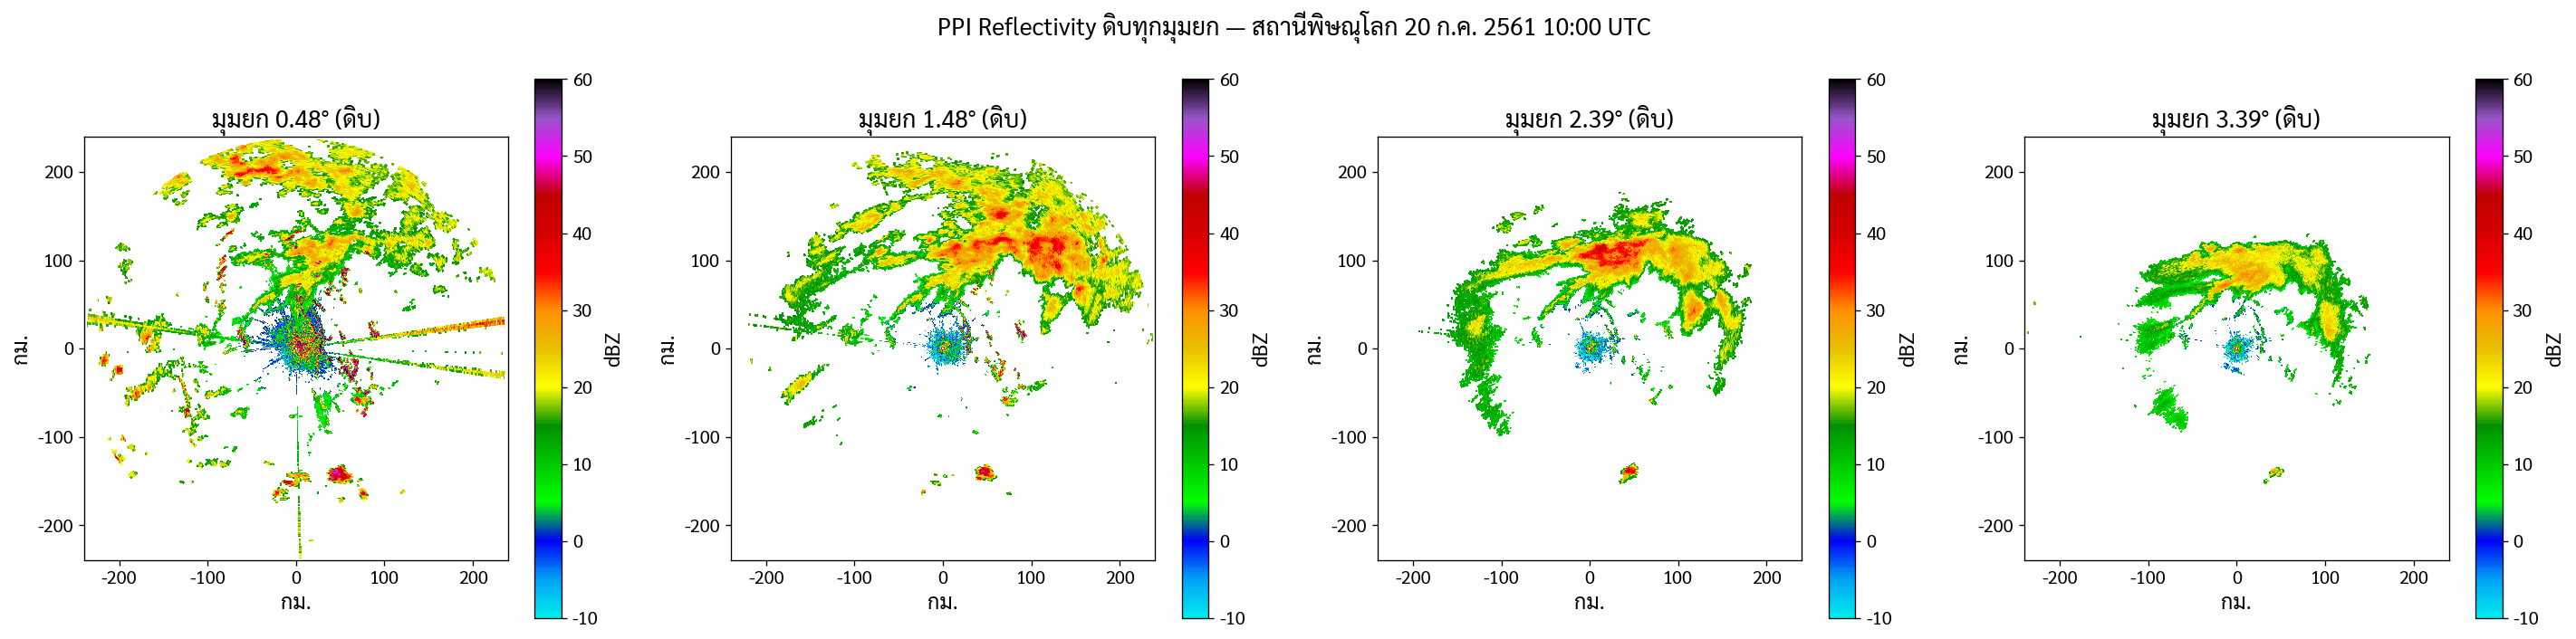

In [ ]:
radar = pyart.io.read(P.RADAR_1000)

def ppi(ax, field, sweep=0, vmin=None, vmax=None, cmap='NWSRef', gf=None, title=None, label=''):
    "helper พลอต PPI แบบพิกัดกิโลเมตร (รูปแบบเดียวกับบทที่ 03)"
    d = pyart.graph.RadarDisplay(radar)
    d.plot(field, sweep=sweep, ax=ax, vmin=vmin, vmax=vmax, cmap=cmap, gatefilter=gf,
           colorbar_label=label, title=title or field)
    ax.set_xlim(-240, 240); ax.set_ylim(-240, 240); ax.set_aspect('equal')
    ax.set_xlabel('กม.'); ax.set_ylabel('กม.')

n_sweeps = radar.nsweeps
fixed_angles = radar.fixed_angle['data']
print("จำนวนมุมยก:", n_sweeps, "| มุมยก (องศา):", [round(float(a), 2) for a in fixed_angles])

fig, axes = plt.subplots(1, n_sweeps, figsize=(6 * n_sweeps, 6))
axes = np.atleast_1d(axes)
for i, ax in enumerate(axes):
    ppi(ax, 'reflectivity', sweep=i, vmin=-10, vmax=60,
        title=f'มุมยก {fixed_angles[i]:.2f}° (ดิบ)', label='dBZ')
plt.suptitle('PPI Reflectivity ดิบทุกมุมยก — สถานีพิษณุโลก 20 ก.ค. 2561 10:00 UTC', fontsize=16)
plt.tight_layout()
fig.savefig(os.path.join(OUT, '0_ppi_raw_all_sweeps.png'), dpi=200, bbox_inches='tight')
plt.show()

**การแปลผล:** สังเกต speckle กระจายรอบสถานีในทุกมุมยก (โดยเฉพาะมุมยกต่ำ) — นี่คือ noise/clutter ที่จะกรองออกในหัวข้อถัดไปด้วยวิธีเดียวกับบทที่ 03


## 1️⃣ กรองคุณภาพสัญญาณ: เลือก TOA → SNR + RHOHV + texture-based (แบบบทที่ 03)

ทำตามขั้นตอนของบทที่ 03: ทดสอบ TOA (top-of-atmosphere) ที่เหมาะสมก่อนคำนวณ SNR แล้วรวมเงื่อนไข SNR + RHOHV + texture-based เป็นตัวกรองเดียว — รายละเอียดการทดสอบ sensitivity เต็มรูปแบบอยู่ในบทที่ 03 A5 บทนี้แสดงแบบย่อเพื่อยืนยันค่าที่เลือกก่อนนำไปใช้


In [ ]:
# ตรวจสอบ TOA แบบย่อ (รายละเอียดเต็มอยู่ในบทที่ 03 A5)
toa_candidates = [10000., 15000., 20000., 25000.]
rows = []
for toa in toa_candidates:
    snr_try = pyart.retrieve.calculate_snr_from_reflectivity(radar, refl_field='reflectivity', toa=toa)
    valid = ~np.ma.getmaskarray(snr_try['data'])
    rows.append({'TOA (m)': int(toa), '% ข้อมูลใช้ได้': round(100 * valid.mean(), 1)})
display(pd.DataFrame(rows))

TOA = 15000.0   # เลือกจากผลด้านบน (ค่าเดียวกับที่บทที่ 03 แนะนำ): ให้สัดส่วนข้อมูลใช้ได้สูงและไม่กว้างเกินจนรวม noise
snr = pyart.retrieve.calculate_snr_from_reflectivity(radar, refl_field='reflectivity', toa=TOA)
radar.add_field('signal_to_noise_ratio', snr, replace_existing=True)
print(f"เลือก TOA = {int(TOA):,} เมตร")

,TOA (m),% ข้อมูลใช้ได้
0,10000,24.5
1,15000,24.5
2,20000,0.0
3,25000,0.0


เลือก TOA = 15,000 เมตร


In [ ]:
SNR_MIN, SNR_MAX = 3.0, 60.0     # เกณฑ์ SNR เดียวกับบทที่ 03
RHOHV_MIN = 0.80                # เกณฑ์ RHOHV เดียวกับบทที่ 03

try:
    gf = pyart.filters.moment_and_texture_based_gate_filter(radar, phi_field='differential_phase')
    used = 'moment_and_texture_based_gate_filter + SNR'
except Exception as e:
    print("ใช้ texture-based ไม่ได้ ใช้ RHOHV แทน:", repr(e))
    gf = pyart.filters.GateFilter(radar)
    gf.exclude_below('cross_correlation_ratio', RHOHV_MIN)
    used = 'RHOHV + SNR (fallback)'

gf.exclude_below('signal_to_noise_ratio', SNR_MIN)
gf.exclude_above('signal_to_noise_ratio', SNR_MAX)
gf.exclude_below('cross_correlation_ratio', RHOHV_MIN)

# สร้างฟิลด์ filtered_reflectivity โดย mask ตามตัวกรองรวม (เหมือนบทที่ 03)
radar.add_field_like('reflectivity', 'filtered_reflectivity',
                     radar.fields['reflectivity']['data'].copy(), replace_existing=True)
nf = radar.fields['filtered_reflectivity']
nf['data'] = np.ma.masked_where(gf.gate_excluded, nf['data'])

refl = radar.fields['reflectivity']['data']
valid = ~np.ma.getmaskarray(refl)
pct_excluded = 100.0 * (gf.gate_excluded & valid).sum() / max(int(valid.sum()), 1)
print("ตัวกรองที่ใช้:", used)
print(f"เกณฑ์: SNR {SNR_MIN}-{SNR_MAX} dB, RHOHV ≥ {RHOHV_MIN}")
print(f"echo จริงที่ถูกตัดออก: {pct_excluded:.1f}%")

ตัวกรองที่ใช้: moment_and_texture_based_gate_filter + SNR
เกณฑ์: SNR 3.0-60.0 dB, RHOHV ≥ 0.8
echo จริงที่ถูกตัดออก: 76.6%


**การแปลผล:** ตัวกรองรวม SNR+RHOHV(+texture) ตัด noise/clutter ออกในสัดส่วนที่เหมาะสม โดยไม่ตัดฝนจริงมากเกินไป — ค่าที่เลือกอ้างอิงจากการทดสอบ sensitivity ในบทที่ 03


## 2️⃣ เปรียบเทียบ PPI ก่อน–หลังกรอง **ทุกมุมยก**

พลอต PPI ก่อน/หลังกรองเรียงเป็นคู่ในทุกมุมยก เพื่อยืนยันว่าตัวกรองทำงานสม่ำเสมอในทุกระดับความสูง ไม่ใช่แค่มุมยกต่ำสุด


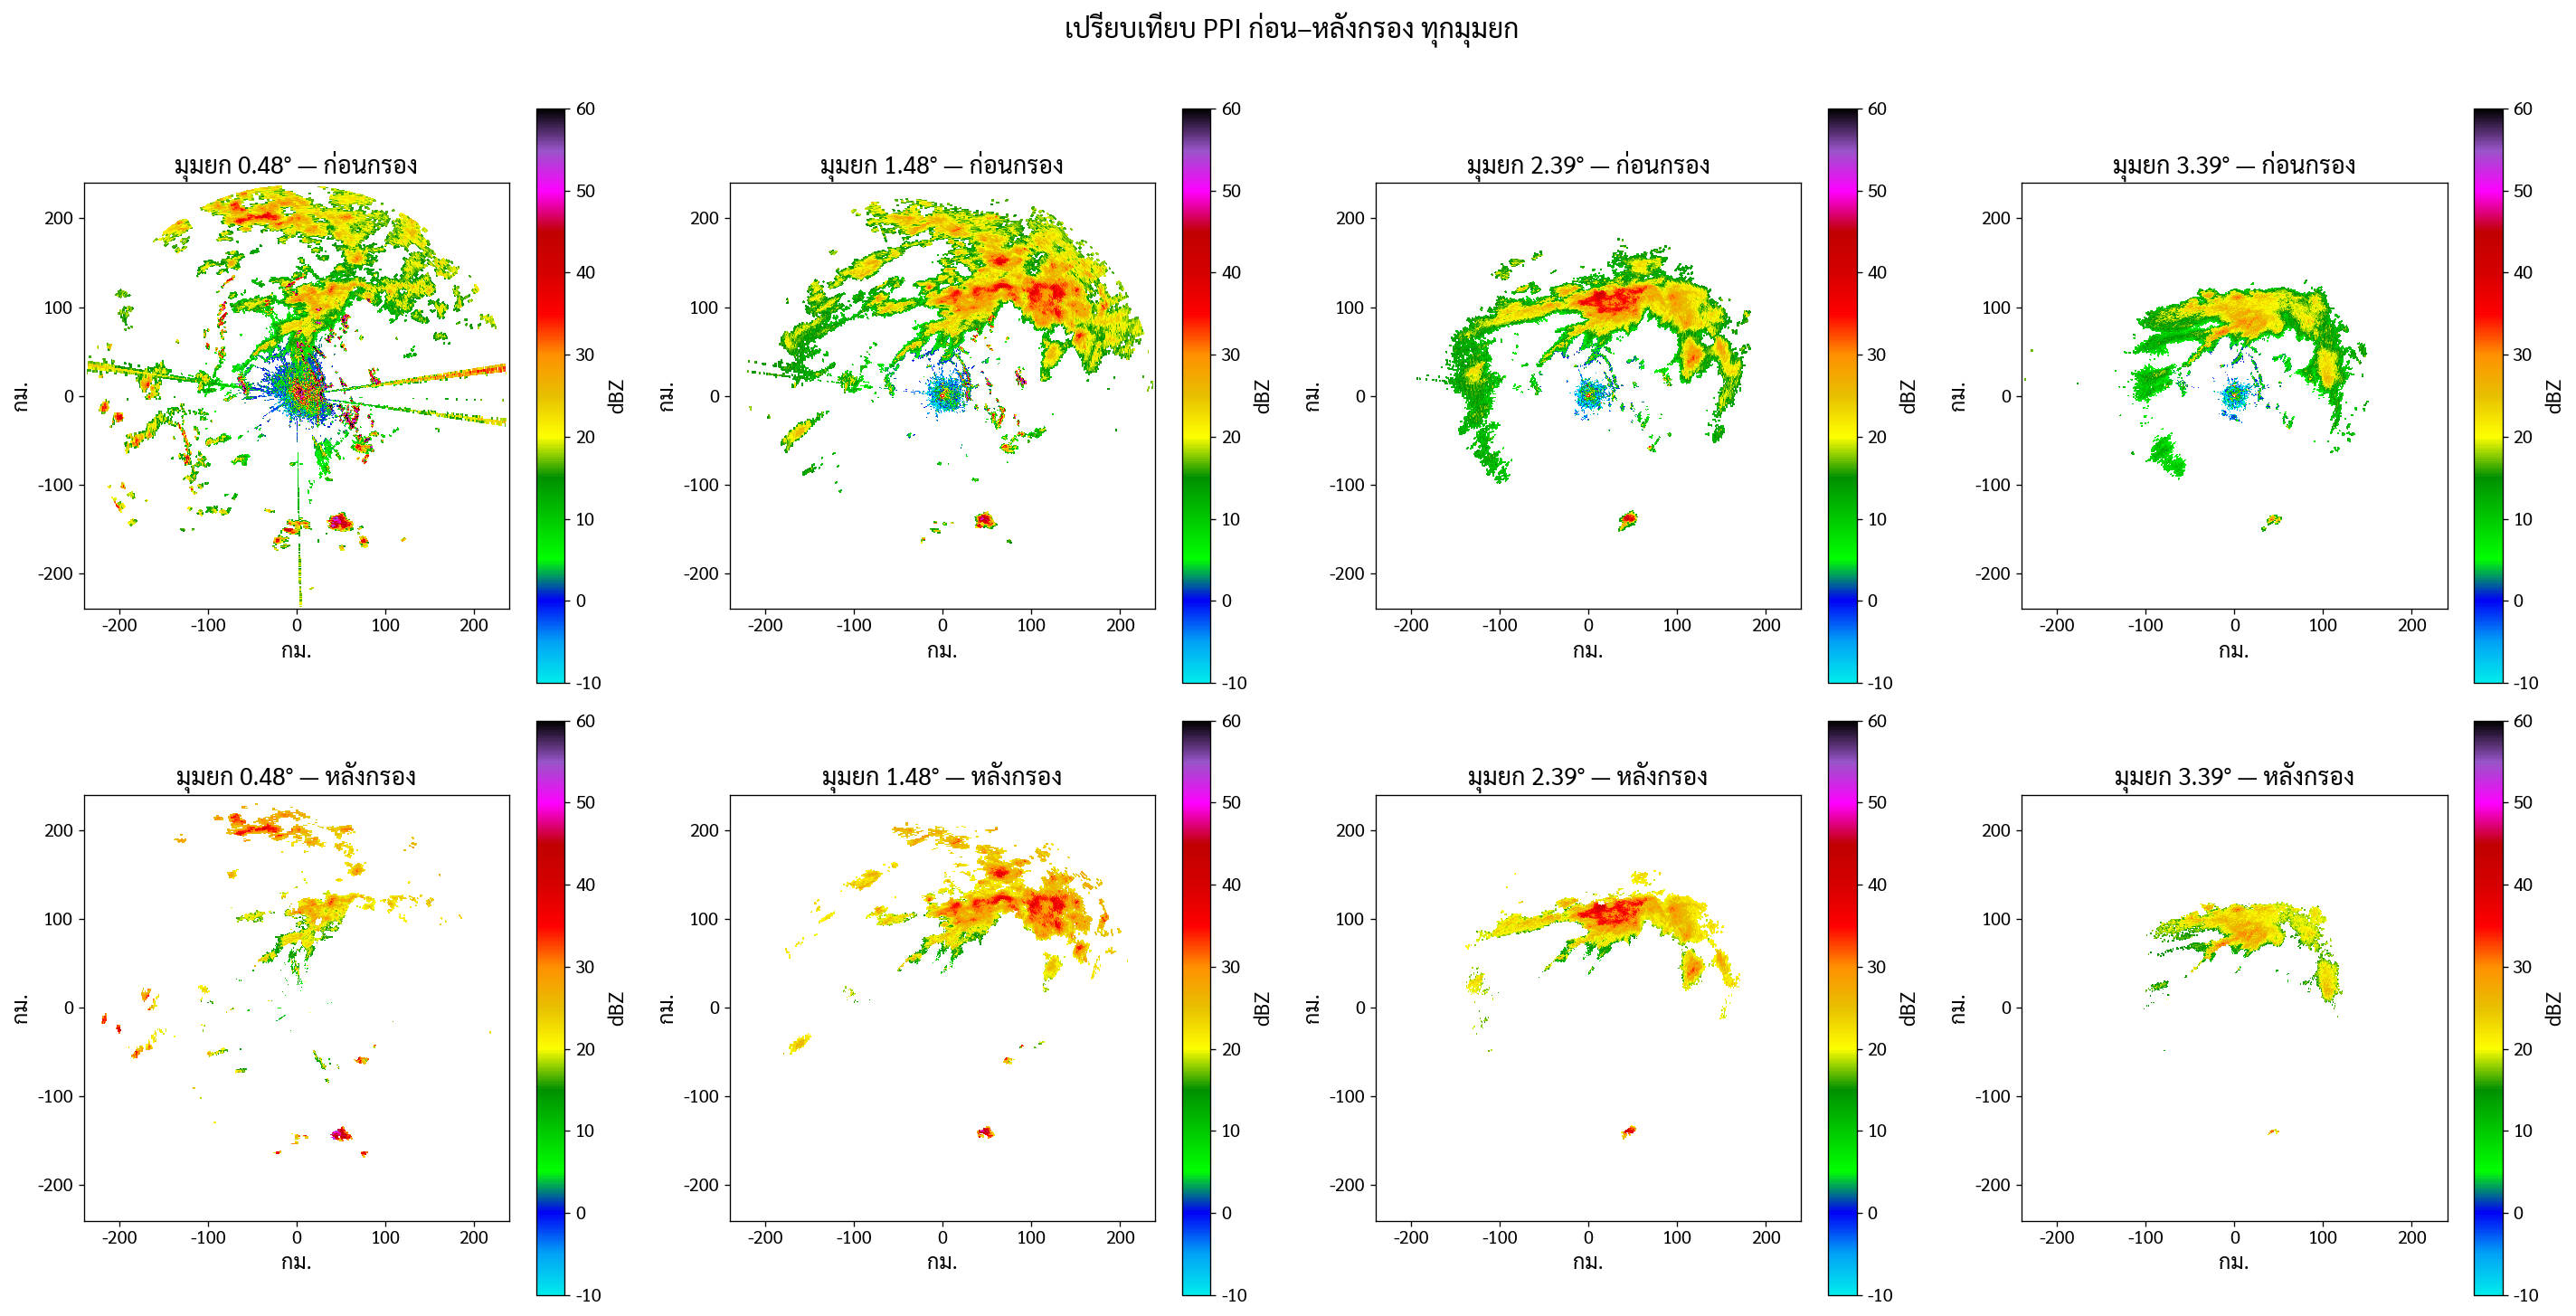

In [ ]:
fig, axes = plt.subplots(2, n_sweeps, figsize=(6 * n_sweeps, 12))
for i in range(n_sweeps):
    ppi(axes[0, i], 'reflectivity', sweep=i, vmin=-10, vmax=60,
        title=f'มุมยก {fixed_angles[i]:.2f}° — ก่อนกรอง', label='dBZ')
    ppi(axes[1, i], 'reflectivity', sweep=i, vmin=-10, vmax=60, gf=gf,
        title=f'มุมยก {fixed_angles[i]:.2f}° — หลังกรอง', label='dBZ')
plt.suptitle('เปรียบเทียบ PPI ก่อน–หลังกรอง ทุกมุมยก', fontsize=18, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(OUT, '2_ppi_before_after_all_sweeps.png'), dpi=200, bbox_inches='tight')
plt.show()

**การแปลผล:** แถวบน (ก่อนกรอง) มี speckle รอบสถานีในทุกมุมยก ส่วนแถวล่าง (หลังกรอง) เหลือเฉพาะฝนที่มีลายเซ็นสัญญาณดี — ผลของตัวกรองสม่ำเสมอในทุกระดับความสูง จึงมั่นใจนำไปสร้าง CAPPI ต่อได้


## 3️⃣ สร้าง CAPPI 2 กม. ก่อน–หลังกรอง แล้วเทียบผลต่อการประเมินฝน

สร้างกริด CAPPI สองแบบ (จาก `reflectivity` ดิบ ไม่ใส่ gatefilter กับจาก `reflectivity` ที่ใส่ gatefilter ตัวเดียวกับหัวข้อ 1–2) แล้วเทียบทั้งภาพและปริมาณฝนเฉลี่ยโดยประมาณ (Z–R แบบ Marshall–Palmer)


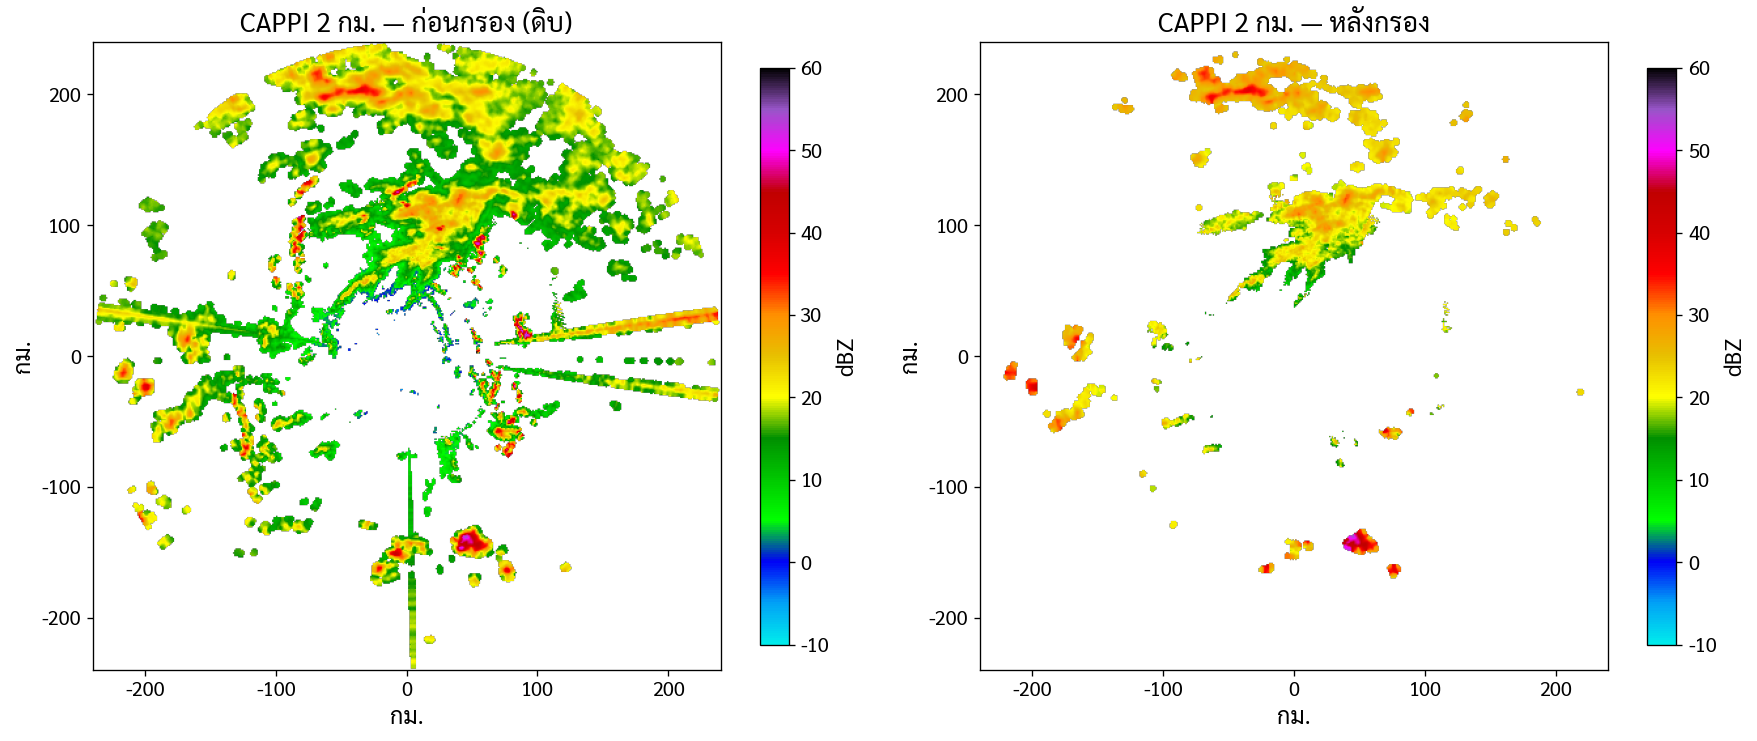

ฝนเฉลี่ยโดยประมาณ (CAPPI 2 กม.)  ก่อนกรอง=0.202  หลังกรอง=0.108 mm/hr
ผลต่าง: 87.0% ของค่าที่กรองแล้ว


In [ ]:
def make_grid(gatefilters=None):
    return pyart.map.grid_from_radars(
        (radar,),
        gatefilters=gatefilters,
        grid_shape=(1, 481, 481),
        grid_limits=((2000.0, 2000.0), (-240000.0, 240000.0), (-240000.0, 240000.0)),
        fields=['reflectivity'],
        weighting_function='Barnes2',
    )

grid_raw = make_grid(gatefilters=None)
grid_qc  = make_grid(gatefilters=(gf,))

z_raw = grid_raw.fields['reflectivity']['data'][0]
z_qc  = grid_qc.fields['reflectivity']['data'][0]

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
for ax, arr, t in zip(axes, [z_raw, z_qc], ['CAPPI 2 กม. — ก่อนกรอง (ดิบ)', 'CAPPI 2 กม. — หลังกรอง']):
    pm = ax.imshow(np.ma.filled(arr, np.nan), origin='lower', extent=[-240, 240, -240, 240],
                   cmap='NWSRef', vmin=-10, vmax=60)
    ax.set_title(t); ax.set_xlabel('กม.'); ax.set_ylabel('กม.'); ax.set_aspect('equal')
    plt.colorbar(pm, ax=ax, shrink=0.8, label='dBZ')
plt.tight_layout()
fig.savefig(os.path.join(OUT, '3_cappi_before_after.png'), dpi=200, bbox_inches='tight')
plt.show()

def meanrain(cappi):
    "ประมาณฝนเฉลี่ยด้วยสมการ Z-R แบบ Marshall–Palmer (Z=200R^1.6)"
    arr = np.ma.filled(cappi, np.nan)
    R = (10.0 ** (arr / 10.0) / 200.0) ** (1 / 1.6)
    return np.nanmean(np.where(arr > 0, R, 0))

r_raw, r_qc = meanrain(z_raw), meanrain(z_qc)
print(f"ฝนเฉลี่ยโดยประมาณ (CAPPI 2 กม.)  ก่อนกรอง={r_raw:.3f}  หลังกรอง={r_qc:.3f} mm/hr")
print(f"ผลต่าง: {100 * (r_raw - r_qc) / max(r_qc, 1e-6):.1f}% ของค่าที่กรองแล้ว")

**การแปลผล:** CAPPI ก่อนกรองมี speckle กระจายรอบสถานีที่ทำให้พื้นที่ฝน/ปริมาณฝนเฉลี่ยประเมินสูงเกินจริง — ตัวกรองจากหัวข้อ 1 ทำให้ CAPPI สะอาดขึ้นและเป็นตัวแทนของฝนจริงมากขึ้น จากนี้ไปบทจะใช้ **CAPPI ที่กรองแล้ว (`z_qc`)** ในการทำแผนที่ทั้งหมด


## 4️⃣ แผนที่ระบบภูมิศาสตร์ (lat/lon) + ขอบเขตจังหวัด

ใช้ CAPPI ที่กรองแล้ว (`z_qc` จากหัวข้อ 3) สร้างแผนที่ระดับตีพิมพ์ในระบบพิกัดภูมิศาสตร์ พร้อมองค์ประกอบแผนที่มาตรฐาน


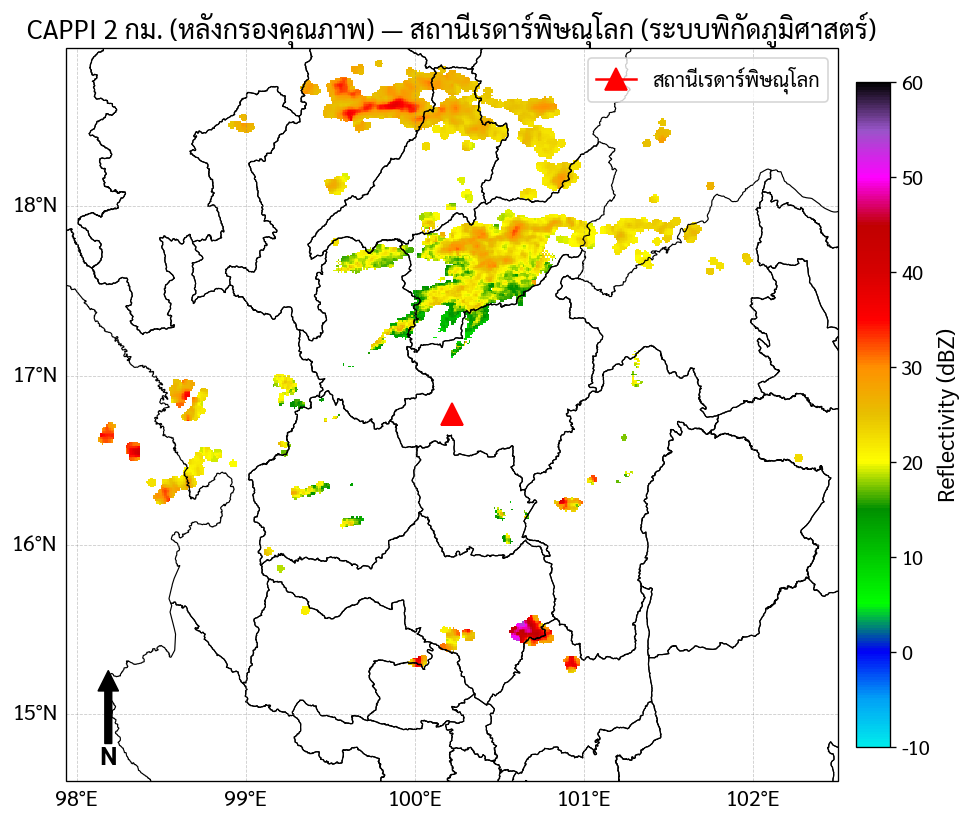

In [ ]:
import cartopy.crs as ccrs

z = z_qc  # ใช้ CAPPI ที่กรองแล้วต่อจากนี้
lons, lats = grid_qc.get_point_longitude_latitude(level=0)    # 2D arrays (องศา)
lon0 = float(radar.longitude['data'][0]); lat0 = float(radar.latitude['data'][0])

# อ่านขอบเขตจังหวัด (ตั้ง CRS เป็น 4326 ถ้าไฟล์ไม่ระบุ)
prov = gpd.read_file(P.PROVINCE_SHP)
if prov.crs is None:
    prov = prov.set_crs('EPSG:4326')

def add_north_arrow(ax):
    "ใส่ลูกศรทิศเหนือมุมซ้ายบน (ใช้ได้ทั้ง GeoAxes และแกนปกติ)"
    ax.annotate('N', xy=(0.055, 0.15), xytext=(0.055, 0.03), xycoords='axes fraction',
                arrowprops=dict(facecolor='black', width=4, headwidth=12),
                ha='center', va='center', fontsize=15, fontweight='bold')

# ── แผนที่ภูมิศาสตร์ ──
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
pm = ax.pcolormesh(lons, lats, z, cmap='NWSRef', vmin=-10, vmax=60,
                   transform=ccrs.PlateCarree(), shading='auto')
# ซ้อนขอบเขตจังหวัด
ax.add_geometries(prov.geometry, crs=ccrs.PlateCarree(),
                  facecolor='none', edgecolor='black', linewidth=0.7)
# ตำแหน่งสถานี
ax.plot(lon0, lat0, marker='^', color='red', markersize=13,
        transform=ccrs.PlateCarree(), label='สถานีเรดาร์พิษณุโลก')

ax.set_extent([lons.min(), lons.max(), lats.min(), lats.max()], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.4, linestyle='--')
gl.top_labels = False; gl.right_labels = False
add_north_arrow(ax)
ax.legend(loc='upper right', fontsize=12)
cb = plt.colorbar(pm, ax=ax, shrink=0.72, pad=0.02)
cb.set_label('Reflectivity (dBZ)', fontsize=14)
ax.set_title('CAPPI 2 กม. (หลังกรองคุณภาพ) — สถานีเรดาร์พิษณุโลก (ระบบพิกัดภูมิศาสตร์)', fontsize=16)

fig.savefig(os.path.join(OUT, '4_cappi2km_geographic.png'), dpi=300, bbox_inches='tight')
plt.show()

## 5️⃣ แผนที่ระบบ UTM Zone 47N (หน่วยเมตร) + ขอบเขตจังหวัด

แปลงพิกัดกริดและ shapefile เป็น UTM (EPSG:32647) แล้วพลอตในระบบเดียวกัน (แสดงแกนเป็นกิโลเมตรเพื่ออ่านง่าย)


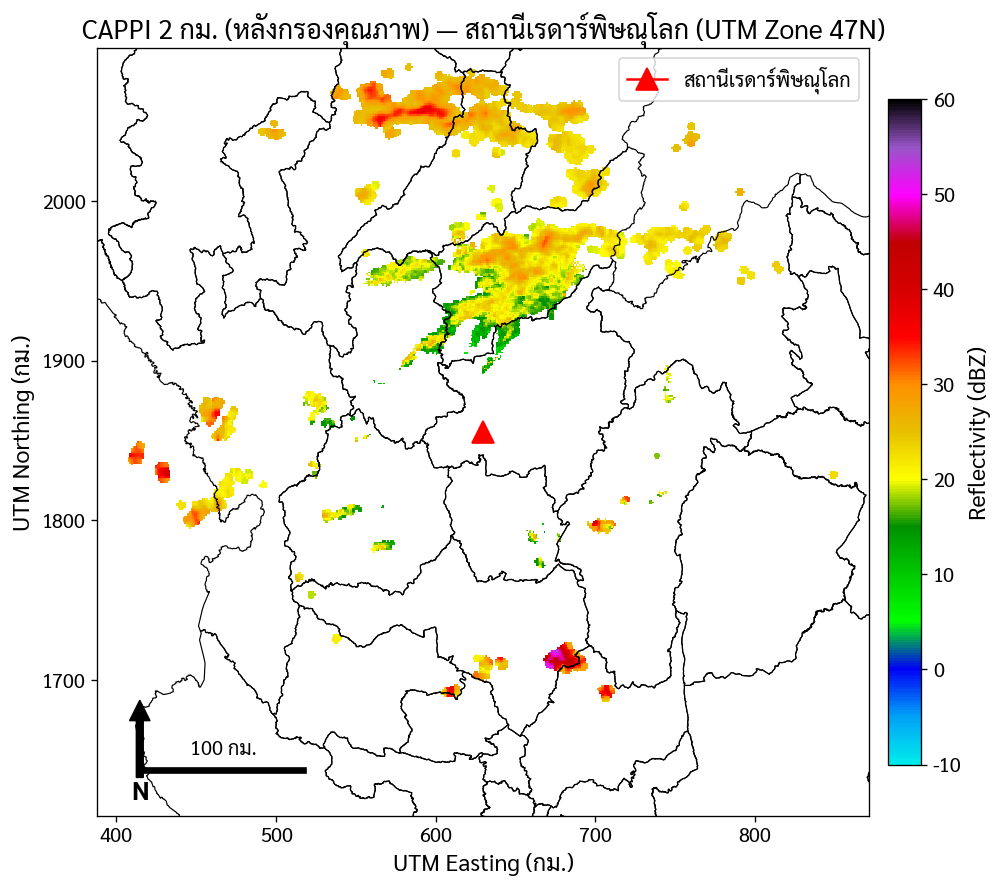

In [ ]:
from pyproj import Transformer
from matplotlib.ticker import FuncFormatter

# แปลงพิกัดกริด lon/lat → UTM (เมตร)
tr = Transformer.from_crs('EPSG:4326', P.UTM47N, always_xy=True)
X, Y = tr.transform(lons, lats)          # 2D arrays หน่วยเมตร
prov_utm = prov.to_crs(P.UTM47N)         # ขอบเขตจังหวัดในระบบ UTM

def add_scalebar_m(ax, length_m=100000, label='100 กม.'):
    "มาตราส่วนอย่างง่ายสำหรับแกนหน่วยเมตร"
    x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim()
    xs = x0 + (x1 - x0)*0.06; ys = y0 + (y1 - y0)*0.06
    ax.plot([xs, xs + length_m], [ys, ys], color='black', lw=4)
    ax.text(xs + length_m/2, ys + (y1 - y0)*0.015, label, ha='center', va='bottom', fontsize=12)

fig, ax = plt.subplots(figsize=(10, 10))
pm = ax.pcolormesh(X, Y, z, cmap='NWSRef', vmin=-10, vmax=60, shading='auto')
prov_utm.boundary.plot(ax=ax, edgecolor='black', linewidth=0.7)
# สถานี
x0m, y0m = tr.transform(lon0, lat0)
ax.plot(x0m, y0m, marker='^', color='red', markersize=13, label='สถานีเรดาร์พิษณุโลก')

ax.set_xlim(X.min(), X.max()); ax.set_ylim(Y.min(), Y.max())
ax.set_aspect('equal')
# แสดงแกนเป็นกิโลเมตร (ข้อมูลจริงเป็นเมตร)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v/1000:.0f}'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v/1000:.0f}'))
ax.set_xlabel('UTM Easting (กม.)', fontsize=14)
ax.set_ylabel('UTM Northing (กม.)', fontsize=14)
add_scalebar_m(ax); add_north_arrow(ax)
ax.legend(loc='upper right', fontsize=12)
cb = plt.colorbar(pm, ax=ax, shrink=0.72, pad=0.02)
cb.set_label('Reflectivity (dBZ)', fontsize=14)
ax.set_title('CAPPI 2 กม. (หลังกรองคุณภาพ) — สถานีเรดาร์พิษณุโลก (UTM Zone 47N)', fontsize=16)

fig.savefig(os.path.join(OUT, '5_cappi2km_utm.png'), dpi=300, bbox_inches='tight')
plt.show()

## 6️⃣ ส่งออกเป็น GeoTIFF สำหรับ QGIS

เขียน GeoTIFF จาก **กริดที่กรองคุณภาพแล้ว** (`grid_qc`) ด้วย **rasterio โดยตรง** แทน `pyart.io.write_grid_geotiff` เพราะฟังก์ชันนั้นต้องพึ่งไลบรารี GDAL python bindings (`osgeo`) ซึ่งไม่ได้อยู่ใน `%pip install` ด้านบนและมักไม่มีติดตั้งไว้ใน Colab โดยค่าเริ่มต้น — ใช้ rasterio (ซึ่งติดตั้งไว้แล้ว) เขียนไฟล์ต้นทางในโปรเจกชัน Py-ART (AEQD) แล้ว reproject เป็น WGS84 ให้เปิดใน QGIS ได้ทันที


In [ ]:
import rasterio
from rasterio.transform import from_origin
from rasterio.warp import calculate_default_transform, reproject, Resampling
from pyproj import CRS

def pyart_grid_crs(grid_object) -> CRS:
    "แปลง projection parameters ของ Py-ART Grid เป็น pyproj CRS (aeqd)"
    params = dict(grid_object.get_projparams())
    params.pop('_include_lon_0_lat_0', None)
    if params.get('proj') == 'pyart_aeqd':
        params['proj'] = 'aeqd'
    params.setdefault('lat_0', float(grid_object.origin_latitude['data'][0]))
    params.setdefault('lon_0', float(grid_object.origin_longitude['data'][0]))
    params.setdefault('units', 'm')
    return CRS.from_user_input(params)

GRID_CRS = pyart_grid_crs(grid_qc)
NODATA_VALUE = -9999.0

gx = np.asarray(grid_qc.x['data'], dtype=float)
gy = np.asarray(grid_qc.y['data'], dtype=float)
dx = float(np.median(np.diff(gx)))
dy = float(np.median(np.diff(gy)))

source_array = np.ma.filled(z_qc, NODATA_VALUE).astype('float32')
source_array_north_up = np.flipud(source_array)   # แถวแรกต้องอยู่ทางเหนือสำหรับ GeoTIFF

source_transform = from_origin(gx.min() - dx / 2.0, gy.max() + dy / 2.0, abs(dx), abs(dy))

local_tif = '/content/cappi2km_reflectivity_phs_qc_aeqd.tif'
tif_path  = os.path.join(OUT, 'cappi2km_reflectivity_phs_qc_wgs84.tif')   # ปลายทางบน Drive (WGS84)

# 1) เขียน GeoTIFF ต้นทางในโปรเจกชัน Py-ART (AEQD) ลงดิสก์เครื่องก่อน
with rasterio.open(
    local_tif, 'w', driver='GTiff',
    height=source_array_north_up.shape[0], width=source_array_north_up.shape[1],
    count=1, dtype='float32', crs=GRID_CRS, transform=source_transform,
    nodata=NODATA_VALUE, compress='deflate',
) as dst:
    dst.write(source_array_north_up, 1)
    dst.set_band_description(1, 'CAPPI reflectivity (dBZ), QC ผ่านตัวกรองบทที่ 03')

# 2) reproject เป็น WGS84 (EPSG:4326) ให้เปิดใน QGIS ได้ทันที แล้วคัดลอกขึ้น Drive
with rasterio.open(local_tif) as src:
    dst_crs = 'EPSG:4326'
    transform, width, height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds)
    profile = src.profile.copy()
    profile.update(crs=dst_crs, transform=transform, width=width, height=height)
    with rasterio.open(tif_path, 'w', **profile) as dst:
        reproject(
            source=rasterio.band(src, 1), destination=rasterio.band(dst, 1),
            src_transform=src.transform, src_crs=src.crs,
            dst_transform=transform, dst_crs=dst_crs,
            src_nodata=NODATA_VALUE, dst_nodata=NODATA_VALUE,
            resampling=Resampling.bilinear,
        )

print("ส่งออก GeoTIFF (หลังกรองคุณภาพ, WGS84) แล้ว:", tif_path)

# ตรวจสอบไฟล์ที่ได้ด้วย rasterio
with rasterio.open(tif_path) as ds:
    print("  ขนาด:", ds.width, "x", ds.height, "| CRS:", ds.crs, "| จำนวน band:", ds.count)
    print("  ขอบเขต (bounds):", [round(b, 3) for b in ds.bounds])

ส่งออก GeoTIFF (หลังกรองคุณภาพ, WGS84) แล้ว: /content/drive/MyDrive/tmd_radar_course/1results/lesson06/cappi2km_reflectivity_phs_qc_wgs84.tif
  ขนาด: 496 x 473 | CRS: EPSG:4326 | จำนวน band: 1
  ขอบเขต (bounds): [97.935, 14.592, 102.504, 18.948]


## 📝 แบบฝึกหัด

1. เปลี่ยน **ระดับความสูง CAPPI** เป็น 3 กม. หรือ 4 กม. (แก้ค่าใน `grid_limits` ของ `make_grid`) แล้วเทียบแผนที่ — โครงสร้างฝนต่างจาก 2 กม. อย่างไร?
2. **ซูมเข้า** บริเวณจังหวัดพิษณุโลก (ปรับ `set_extent`/`set_xlim,set_ylim` ให้แคบลง) แล้วซ้อน **ขอบเขตอำเภอ** จาก `P.PHITS_SHP` พร้อมใส่ชื่ออำเภอ
3. ปรับ `figsize`/`dpi`/ขนาดฟอนต์ ให้ได้ภาพขนาดคอลัมน์เดียวของวารสาร (กว้าง ~9 ซม. ที่ 300 dpi)
4. **(ต่อยอดจากหัวข้อ 1–3)** ลองเปลี่ยน `SNR_MIN`/`RHOHV_MIN` ให้เข้มขึ้นหรือหลวมลง แล้วรันหัวข้อ 2–3 ใหม่ — สังเกตว่า CAPPI และปริมาณฝนเฉลี่ยเปลี่ยนไปอย่างไร เทียบกับ trade-off ที่บทที่ 03 อธิบายไว้


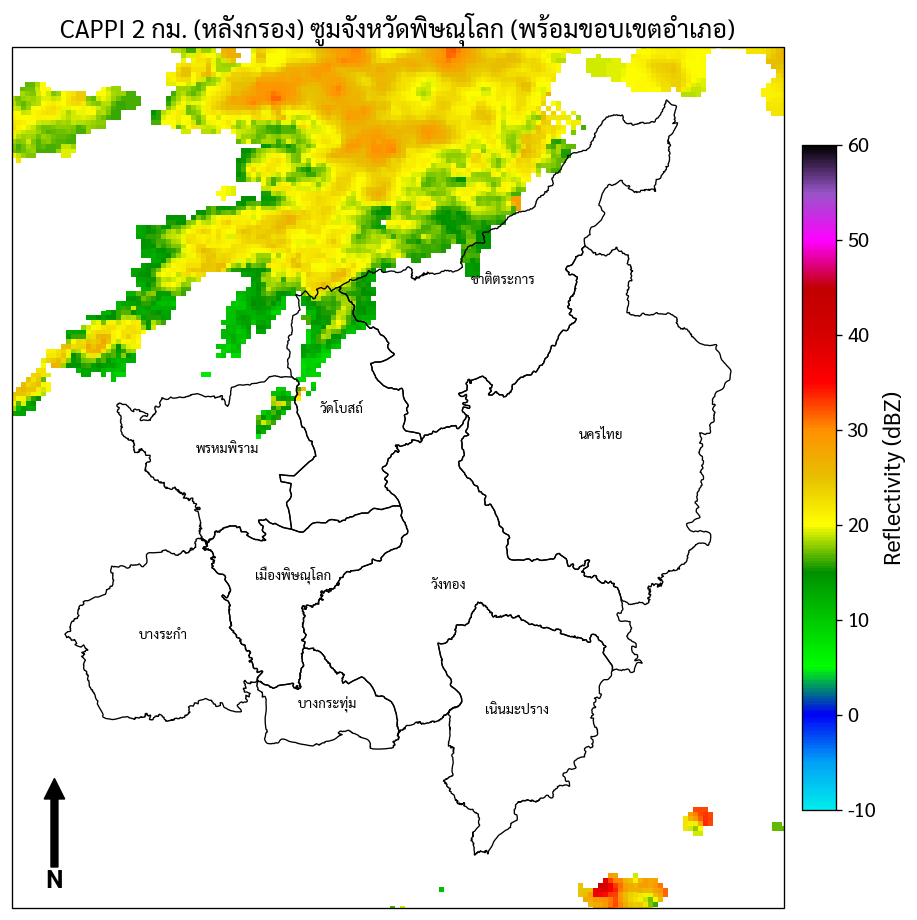

In [ ]:
# แบบฝึกหัดข้อ 2 (โครงเริ่มต้น): ซ้อนขอบเขตอำเภอพิษณุโลก + ชื่ออำเภอ
amphoe = gpd.read_file(P.PHITS_SHP)
if amphoe.crs is None:
    amphoe = amphoe.set_crs('EPSG:4326')

fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
pm = ax.pcolormesh(lons, lats, z, cmap='NWSRef', vmin=-10, vmax=60,
                   transform=ccrs.PlateCarree(), shading='auto')
ax.add_geometries(amphoe.geometry, crs=ccrs.PlateCarree(),
                  facecolor='none', edgecolor='black', linewidth=0.8)
# ใส่ชื่ออำเภอที่จุดศูนย์กลางแต่ละพื้นที่ (ถ้ามีคอลัมน์ชื่อ)
name_col = next((c for c in ('ADM2_TH', 'ADM2_EN', 'AMP_NAM_T', 'AMP_NAM_E', 'name', 'NAME')
                  if c in amphoe.columns), None)
for _, row in amphoe.iterrows():
    c = row.geometry.centroid
    ax.text(c.x, c.y, str(row[name_col]) if name_col else '', fontsize=8,
            ha='center', transform=ccrs.PlateCarree())

# ซูมรอบจังหวัดพิษณุโลก
minx, miny, maxx, maxy = amphoe.total_bounds
ax.set_extent([minx-0.1, maxx+0.1, miny-0.1, maxy+0.1], crs=ccrs.PlateCarree())
cb = plt.colorbar(pm, ax=ax, shrink=0.72, pad=0.02); cb.set_label('Reflectivity (dBZ)')
add_north_arrow(ax)
ax.set_title('CAPPI 2 กม. (หลังกรอง) ซูมจังหวัดพิษณุโลก (พร้อมขอบเขตอำเภอ)', fontsize=15)
plt.show()
# TODO (นิสิต): ทำข้อ 1, 3 และ 4 ต่อ

---
## 🎯 สรุป

- ก่อนทำแผนที่/CAPPI ควร**กรองคุณภาพสัญญาณก่อนเสมอ** — บทนี้ใช้วิธีเดียวกับบทที่ 03: เลือก TOA ที่เหมาะสม → SNR + RHOHV + texture-based
- เปรียบเทียบ **PPI ทุกมุมยก** ก่อน–หลังกรอง ยืนยันว่าตัวกรองทำงานสม่ำเสมอในทุกระดับความสูง ไม่ใช่แค่มุมยกต่ำสุด
- เปรียบเทียบ **CAPPI** ก่อน–หลังกรอง แสดงให้เห็นว่า noise/clutter ที่ไม่กรองทำให้ประเมินพื้นที่ฝน/ปริมาณฝนคลาดเคลื่อน
- แผนที่เรดาร์ทำได้ทั้งระบบ **ภูมิศาสตร์ (องศา)** และ **UTM (เมตร)** — เลือกตามการใช้งาน โดยควรใช้ CAPPI ที่กรองแล้วเสมอ
- ซ้อน shapefile จังหวัด/อำเภอด้วย geopandas + `add_geometries` (cartopy) หรือ `.boundary.plot` (UTM)
- ใส่องค์ประกอบมาตรฐาน (แถบสี/เส้นกริด/มาตราส่วน/ทิศเหนือ) ให้ได้คุณภาพระดับตีพิมพ์
- ส่งออก **GeoTIFF** จากกริดที่กรองแล้ว ด้วย `pyart.io.write_grid_geotiff` เพื่อใช้ต่อใน QGIS

**บทถัดไป:** ต่อยอดสู่การปรับแก้ polarimetric และ QPE (บท 07–08) เพื่อทำแผนที่ **ปริมาณฝน** รายพื้นที่
